In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial
from scipy.stats import halfnorm, norm
from jax import vmap, random
import time
from typing import NamedTuple

def kl_divergence(mean_belief, precision_belief, mean_pref, precision_pref):
    """Calculate the KL divergence between two Gaussian distributions."""
    var_belief = 1 / precision_belief
    var_pref = 1 / precision_pref
    kl = (
        jnp.log(jnp.sqrt(var_pref) / jnp.sqrt(var_belief))
        + (var_belief + (mean_belief - mean_pref) ** 2) / (2 * var_pref)
        - 0.5
    )
    return kl

def generate_random_preferences(key, n_preferences, n_agents=1):
    """Generate random preferences using JAX for better performance."""
    key1, key2 = random.split(key)
    mus = random.normal(key1, shape=(n_agents, n_preferences)) * 1 + 4
    pis = random.halfnormal(key2, shape=(n_agents, n_preferences)) * 0.5
    return mus, pis

class SimulationState(NamedTuple):
    """State of the simulation for JAX compatibility."""
    mus: jnp.ndarray
    pis: jnp.ndarray
    tonic_volatilities: jnp.ndarray

class Simulation:
    def __init__(self, n_agents, n_preferences, n_candidates, voting_system="basic"):
        """Initialize the simulation with parameters."""
        self.n_agents = n_agents
        self.n_preferences = n_preferences
        self.n_candidates = n_candidates
        self.voting_system = voting_system
        self.key = random.PRNGKey(int(time.time()))

    def initialize_agents(self):
        """Initialize agent preferences and volatilities using JAX."""
        self.key, subkey = random.split(self.key)
        mus, pis = generate_random_preferences(subkey, self.n_preferences, self.n_agents)
        tonic_volatilities = random.normal(subkey, (self.n_agents,)) * 1.0 - 3.0

        return SimulationState(
            mus=mus,
            pis=pis,
            tonic_volatilities=tonic_volatilities
        )

    def generate_candidates(self):
        """Generate random candidates using JAX."""
        self.key, subkey1, subkey2 = random.split(self.key, 3)
        manual_means = random.normal(subkey1, (self.n_candidates, self.n_preferences)) * 1 + 2
        manual_precisions = jnp.abs(random.normal(subkey2, (self.n_candidates, self.n_preferences)) * 0.1 + 0.5)
        return [(manual_means[i], manual_precisions[i]) for i in range(self.n_candidates)]

    def generate_observations(self, n_steps=500):
        """Generate observations using numpy (not JAX for this part)."""
        np.random.seed(42)
        phase1_params = (15, 1)

        def generate_beta(params, size):
            a, b = params
            obs = np.random.beta(a, b, size=size)
            obs += np.random.normal(0, 0.05, size=size)
            return np.clip(obs, 0, 1)

        node_observations = []
        for node in range(self.n_preferences):
            node_observations.append(generate_beta(phase1_params, n_steps))

        self.input_data = np.column_stack(node_observations)
        return self.input_data

    def compute_votes(self, state, candidates, mask):
        """Vectorized vote computation using JAX."""
        def agent_vote(mu, pi, tonic_volatility, key):
            def candidate_dissatisfaction(candidate):
                mean_pref, precision_pref = candidate
                return jnp.sum(kl_divergence(mu, pi, mean_pref, precision_pref))

            candidate_preferences = jnp.array([candidate_dissatisfaction(c) for c in candidates])
            masked_preferences = jnp.where(mask, candidate_preferences, -jnp.inf)

            if self.voting_system == "basic":
                softmax_probs = jax.nn.softmax(masked_preferences)
                vote = random.categorical(key, jnp.log(softmax_probs))
                return vote, softmax_probs
            else:
                # Simplified - implement other voting systems as needed
                softmax_probs = jax.nn.softmax(masked_preferences)
                vote = random.categorical(key, jnp.log(softmax_probs))
                return vote, softmax_probs

        # Create a batched version of agent_vote
        batched_agent_vote = vmap(agent_vote, in_axes=(0, 0, 0, 0))

        # Generate keys for all agents
        keys = random.split(self.key, self.n_agents)

        # Execute the batched vote computation
        votes, softmax_probs = batched_agent_vote(state.mus, state.pis, state.tonic_volatilities, keys)
        return votes, softmax_probs

    def run_simulation(self):
        """Run the full simulation with vectorized computations."""
        # Initialize
        state = self.initialize_agents()
        candidates = self.generate_candidates()
        mask = jnp.ones(self.n_candidates, dtype=bool)
        self.generate_observations()  # Not used in current voting computation

        # Compute votes using vectorized operations
        votes, softmax_probs = self.compute_votes(state, candidates, mask)

        return votes, softmax_probs

# Exemple d'utilisation avec benchmarking
n_simulations = 10
n_agents_per_simulation = 100
n_preferences = 2
n_candidates = 3

# Création de la simulation
simulation = Simulation(
    n_agents=n_agents_per_simulation * n_simulations,
    n_preferences=n_preferences,
    n_candidates=n_candidates,
    voting_system="basic"
)

# Lancer la simulation et mesurer le temps
start_time = time.time()
votes, softmax_probs = simulation.run_simulation()
end_time = time.time()

print(f"Temps d'exécution: {end_time - start_time:.4f} secondes")
print("Premiers votes:", votes[:10])
print("Premières probas:", softmax_probs[:10])


AttributeError: module 'jax.random' has no attribute 'halfnormal'

In [10]:
import pandas as pd
# Convertir les résultats en format plus lisible
votes_list = np.array(votes)
softmax_probs_list = np.array(softmax_probs)

# Sauvegarder les résultats dans un DataFrame pandas
results_df = pd.DataFrame({
    'vote': votes_list,
    'softmax_probs': [list(probs) for probs in softmax_probs_list]
})

# Afficher les premiers résultats
print(results_df.head())

# Sauvegarder les résultats dans un fichier CSV
results_df.to_csv('simulation_results.csv', index=False)
print("Résultats sauvegardés dans simulation_results.csv")


   vote                             softmax_probs
0     0  [0.9988599, 0.00024526517, 0.0008947938]
1     0     [0.9575453, 0.016628131, 0.025826614]
2     0     [0.9469815, 0.020019244, 0.032999292]
3     0    [0.996197, 0.0014596236, 0.0023434418]
4     0      [0.98045874, 0.0079862, 0.011555034]
Résultats sauvegardés dans simulation_results.csv


Nombre de votes par candidat : [95674  3181  1145]


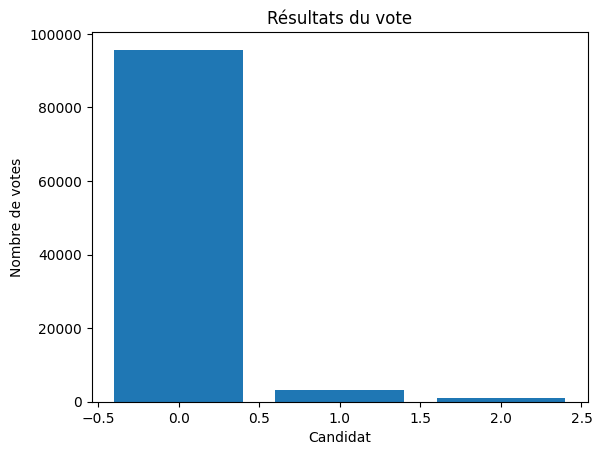

In [11]:
# Analyser les résultats
vote_counts = np.bincount(votes_list.astype(int), minlength=n_candidates)
print("Nombre de votes par candidat :", vote_counts)

# Visualisation rapide (nécessite matplotlib)
import matplotlib.pyplot as plt

plt.bar(range(n_candidates), vote_counts)
plt.xlabel('Candidat')
plt.ylabel('Nombre de votes')
plt.title('Résultats du vote')
plt.show()
